In [1]:
import pandas as pd 
from pathlib import Path

In [5]:
data_path = Path("../../../datasets/Sample - Superstore.csv")
df = pd.read_csv(data_path, encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.shape

(9994, 21)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [8]:
total_revenue  = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 2297200.86
Total Orders: 5009
Average Order Value: 458.61


## KPI Summary

- Total Revenue measures total sales generated
- Total Orders measures the number of unique orders
- Average Order Value shows how much customers spend per order

### Monthly revenue trend

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

monthly_revenue = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_revenue["Order Date"] = monthly_revenue["Order Date"].astype(str)

monthly_revenue.head()

,Order Date,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


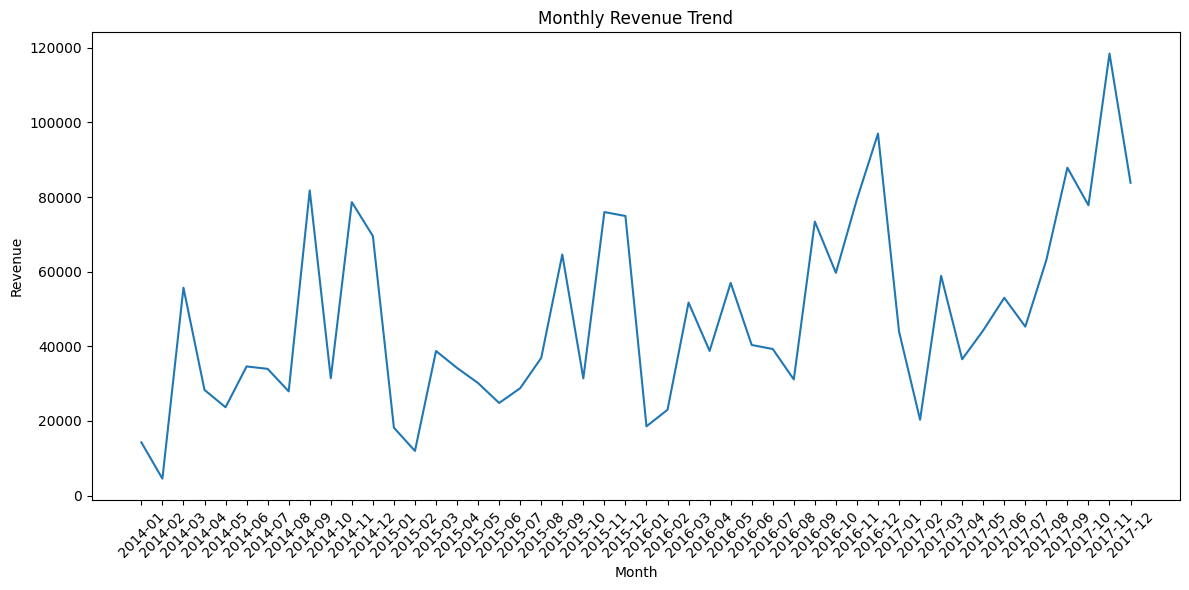

In [14]:
import matplotlib.pyplot as  plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["Order Date"], monthly_revenue["Sales"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Monthly Revenue Insight

This chart shows how revenue changes over time and helps identify trends, seasonality, and stronger or weaker sales periods.

In [15]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales

,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


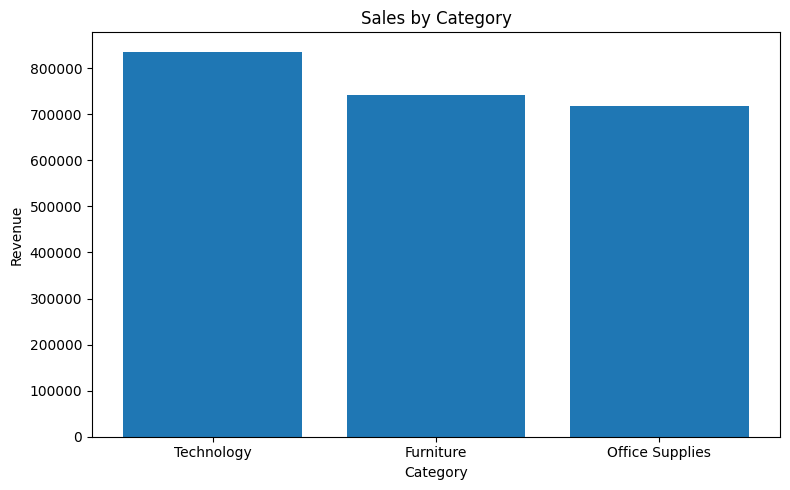

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(category_sales["Category"], category_sales["Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Category Performance Insight

This chart shows which product categories contribute the most revenue and helps identify the strongest areas of the business.

### Region performance 

In [17]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

region_sales

,Region,Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


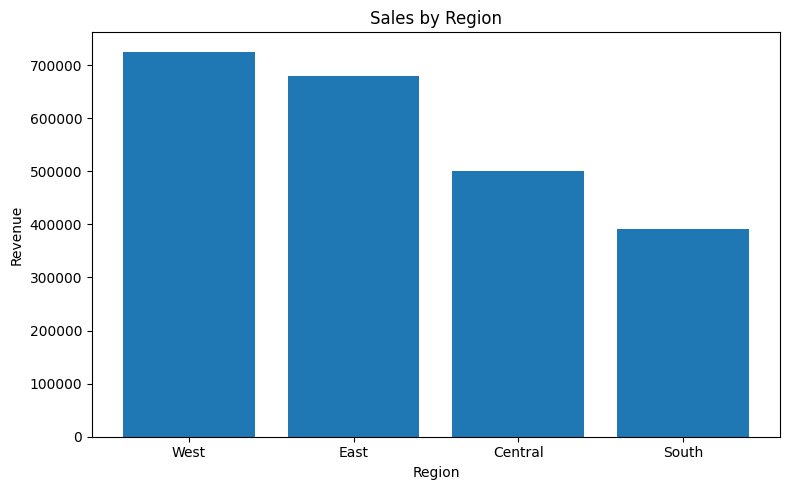

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(region_sales["Region"], region_sales["Sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Region Performance Insight

This chart compares revenue across regions and helps identify the strongest and weakest markets.

In [19]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

subcategory_sales

,Sub-Category,Sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


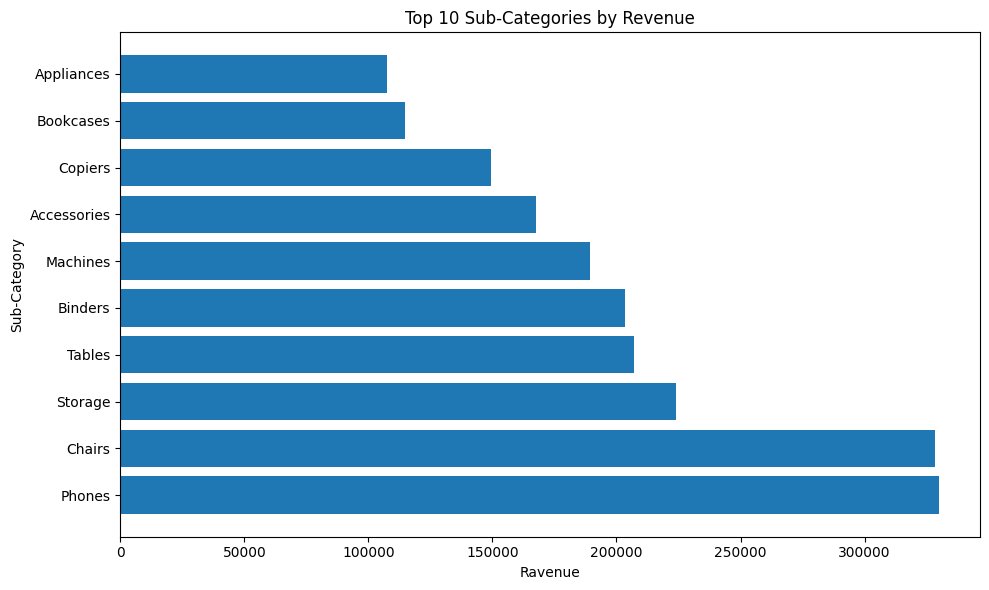

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(subcategory_sales["Sub-Category"], subcategory_sales["Sales"])
plt.title("Top 10 Sub-Categories by Revenue")
plt.xlabel("Ravenue")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

## Sub-Category Insight

This view shows which sub-categories generate the most revenue and helps identify high-performing product segments.